# Investigating the Effect of Network Depth and Width on Multilayer Perceptron Performance using the Iris Dataset

This notebook demonstrates how the architecture of a Multilayer Perceptron (MLP) affects classification performance on the Iris dataset.

## Goals
- Load and explore the Iris dataset
- Train baseline and MLP models
- Compare shallow and deeper neural networks
- Compare narrow and wider networks
- Visualise accuracy, loss curves, confusion matrices, and decision regions

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.decomposition import PCA
from sklearn.inspection import DecisionBoundaryDisplay

In [3]:
import warnings
warnings.filterwarnings("ignore")

# Make plots a little cleaner
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["font.size"] = 11

RANDOM_STATE = 42

In [4]:
iris = load_iris()

X = iris.data
y = iris.target
feature_names = iris.feature_names
class_names = iris.target_names

df = pd.DataFrame(X, columns=feature_names)
df["target"] = y
df["species"] = df["target"].map({i: name for i, name in enumerate(class_names)})

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (150, 6)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [5]:
print("Class names:", class_names)
print("\nClass distribution:")
print(df["species"].value_counts())

print("\nSummary statistics:")
display(df.describe())

Class names: ['setosa' 'versicolor' 'virginica']

Class distribution:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

Summary statistics:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


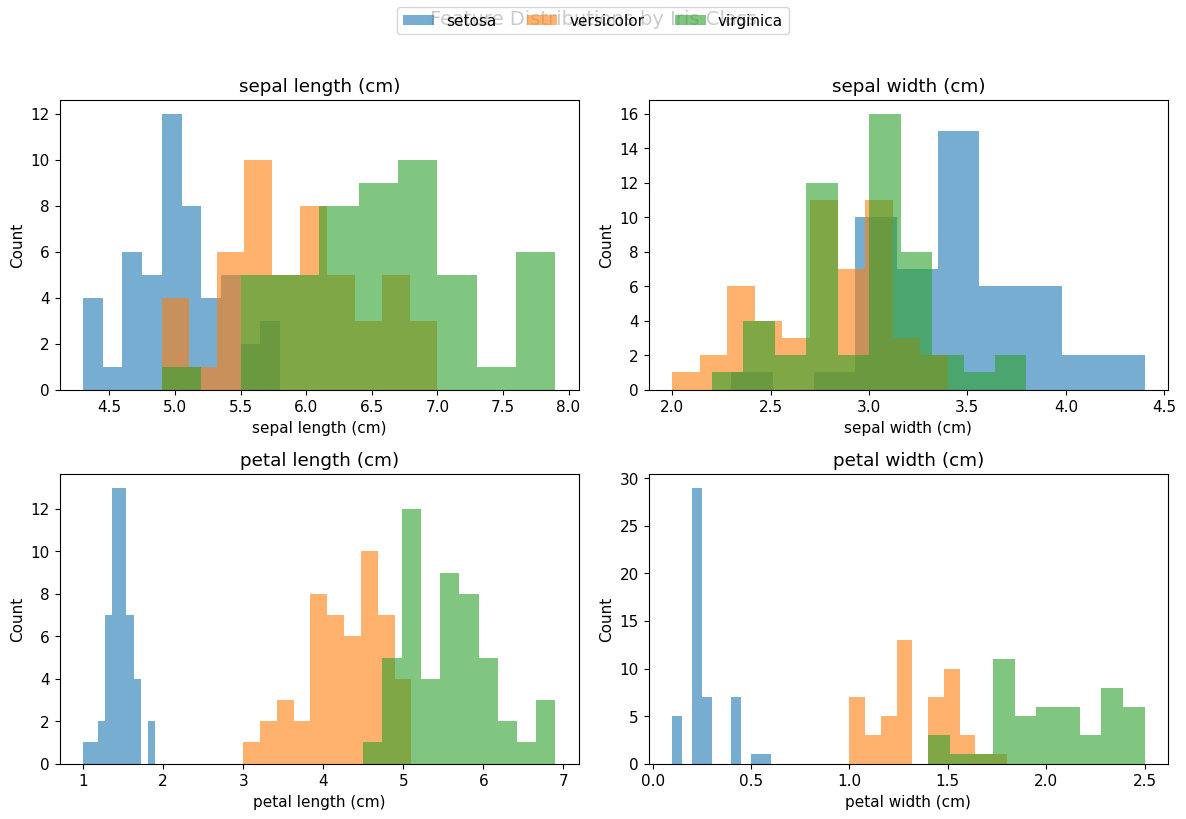

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, col in zip(axes.ravel(), feature_names):
    for class_id, class_name in enumerate(class_names):
        ax.hist(
            df[df["target"] == class_id][col],
            alpha=0.6,
            label=class_name
        )
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel("Count")

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3)
fig.suptitle("Feature Distributions by Iris Class", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Training samples:", X_train.shape[0])
print("Test samples:", X_test.shape[0])

Training samples: 112
Test samples: 38


In [8]:
baseline_model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])

baseline_model.fit(X_train, y_train)
baseline_pred = baseline_model.predict(X_test)
baseline_acc = accuracy_score(y_test, baseline_pred)

print(f"Baseline Logistic Regression Test Accuracy: {baseline_acc:.4f}")

Baseline Logistic Regression Test Accuracy: 0.9211


In [9]:
def build_mlp(hidden_layers, learning_rate_init=0.01, max_iter=1500):
    """
    Create a pipeline with feature scaling and an MLP classifier.
    """
    return Pipeline([
        ("scaler", StandardScaler()),
        ("mlp", MLPClassifier(
            hidden_layer_sizes=hidden_layers,
            activation="relu",
            solver="adam",
            alpha=0.0005,
            learning_rate_init=learning_rate_init,
            max_iter=max_iter,
            random_state=RANDOM_STATE,
            early_stopping=True,
            validation_fraction=0.15,
            n_iter_no_change=30
        ))
    ])

In [10]:
def get_loss_curve(trained_pipeline):
    """
    Extract the training loss curve from the MLP inside the pipeline.
    """
    return trained_pipeline.named_steps["mlp"].loss_curve_


def plot_confusion(y_true, y_pred, labels, title):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(cmap="Blues")
    plt.title(title)
    plt.show()

In [11]:
def evaluate_model(model, X_train, y_train, X_test, y_test):
    """
    Train a model and return key evaluation metrics.
    """
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    return {
        "model": model,
        "accuracy": acc,
        "predictions": y_pred
    }

In [12]:
depth_configs = {
    "1 hidden layer": (10,),
    "2 hidden layers": (10, 10),
    "3 hidden layers": (10, 10, 10),
    "4 hidden layers": (10, 10, 10, 10)
}

depth_results = []

for label, hidden_layers in depth_configs.items():
    model = build_mlp(hidden_layers=hidden_layers)
    result = evaluate_model(model, X_train, y_train, X_test, y_test)
    
    depth_results.append({
        "Configuration": label,
        "Hidden layers": hidden_layers,
        "Depth": len(hidden_layers),
        "Test Accuracy": result["accuracy"],
        "Model": result["model"],
        "Predictions": result["predictions"]
    })

depth_results_df = pd.DataFrame(depth_results).drop(columns=["Model", "Predictions"])
depth_results_df.sort_values("Depth")

,Configuration,Hidden layers,Depth,Test Accuracy
0,1 hidden layer,"(10,)",1,0.894737
1,2 hidden layers,"(10, 10)",2,0.842105
2,3 hidden layers,"(10, 10, 10)",3,0.868421
3,4 hidden layers,"(10, 10, 10, 10)",4,0.868421


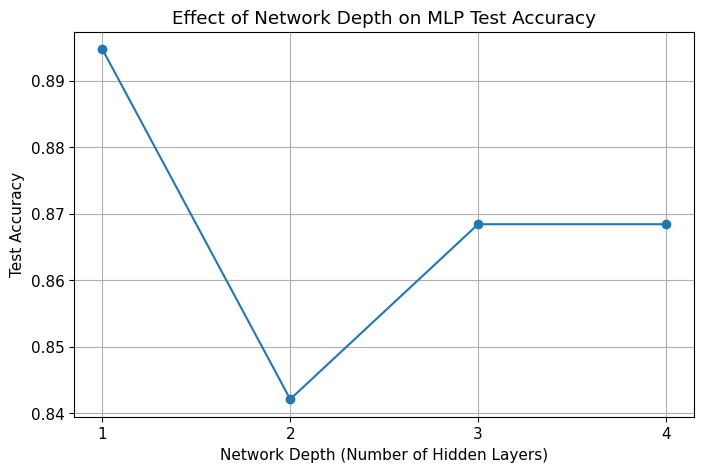

In [13]:
plt.plot(
    depth_results_df["Depth"],
    depth_results_df["Test Accuracy"],
    marker="o"
)
plt.xticks(depth_results_df["Depth"])
plt.xlabel("Network Depth (Number of Hidden Layers)")
plt.ylabel("Test Accuracy")
plt.title("Effect of Network Depth on MLP Test Accuracy")
plt.grid(True)
plt.show()

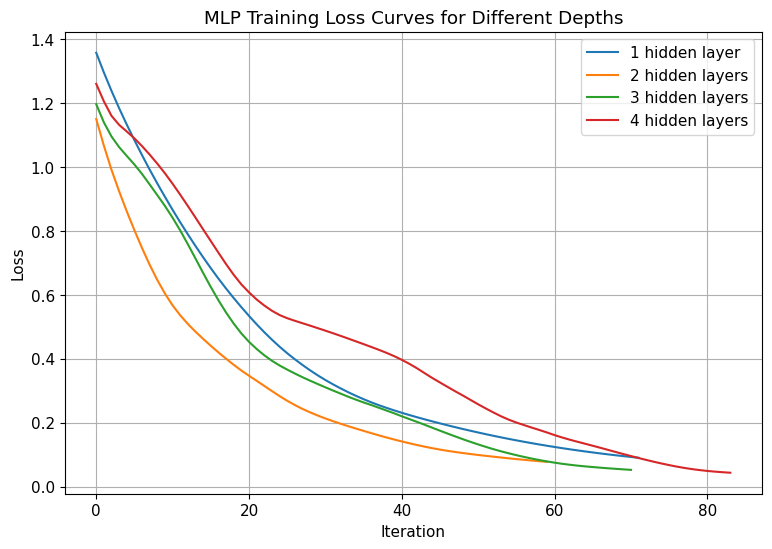

In [14]:
plt.figure(figsize=(9, 6))

for row in depth_results:
    loss_curve = get_loss_curve(row["Model"])
    plt.plot(loss_curve, label=row["Configuration"])

plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("MLP Training Loss Curves for Different Depths")
plt.legend()
plt.grid(True)
plt.show()

1 hidden layer | Accuracy = 0.8947


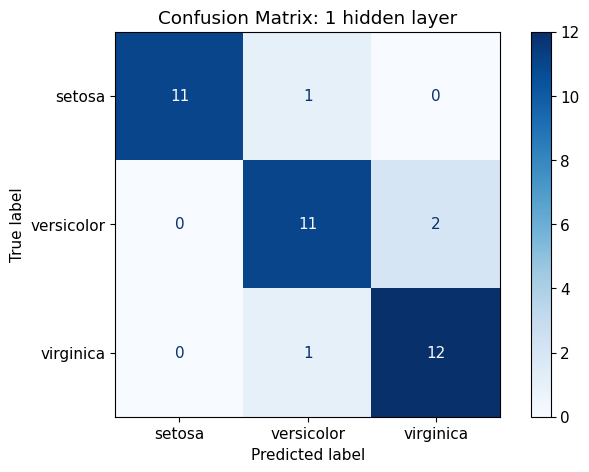

2 hidden layers | Accuracy = 0.8421


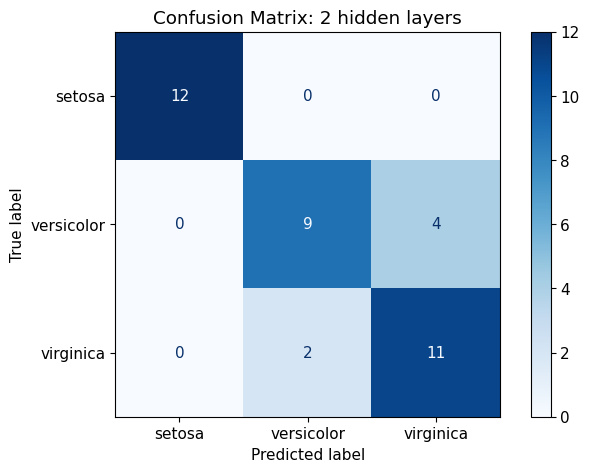

3 hidden layers | Accuracy = 0.8684


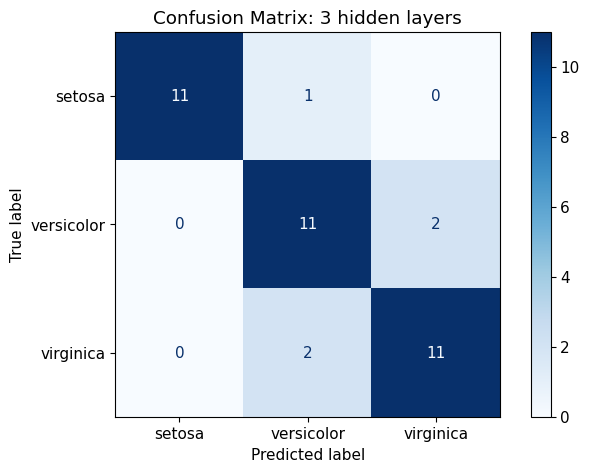

4 hidden layers | Accuracy = 0.8684


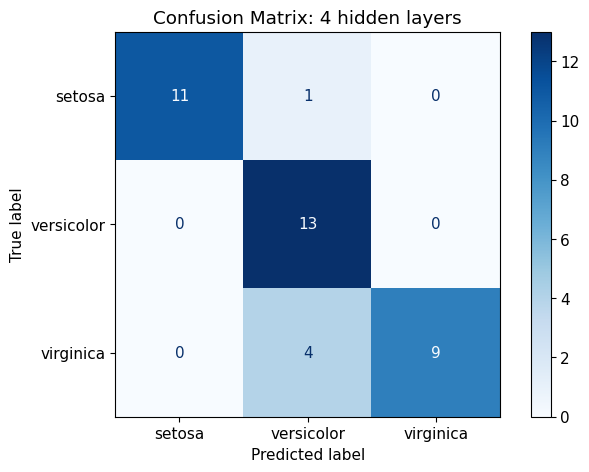

In [15]:
for row in depth_results:
    print(f"{row['Configuration']} | Accuracy = {row['Test Accuracy']:.4f}")
    plot_confusion(
        y_test,
        row["Predictions"],
        class_names,
        f"Confusion Matrix: {row['Configuration']}"
    )

In [16]:
width_configs = {
    "Width 5": (5,),
    "Width 10": (10,),
    "Width 20": (20,),
    "Width 50": (50,)
}

width_results = []

for label, hidden_layers in width_configs.items():
    model = build_mlp(hidden_layers=hidden_layers)
    result = evaluate_model(model, X_train, y_train, X_test, y_test)
    
    width_results.append({
        "Configuration": label,
        "Hidden layers": hidden_layers,
        "Width": hidden_layers[0],
        "Test Accuracy": result["accuracy"],
        "Model": result["model"],
        "Predictions": result["predictions"]
    })

width_results_df = pd.DataFrame(width_results).drop(columns=["Model", "Predictions"])
width_results_df.sort_values("Width")

,Configuration,Hidden layers,Width,Test Accuracy
0,Width 5,"(5,)",5,0.763158
1,Width 10,"(10,)",10,0.894737
2,Width 20,"(20,)",20,0.894737
3,Width 50,"(50,)",50,0.815789


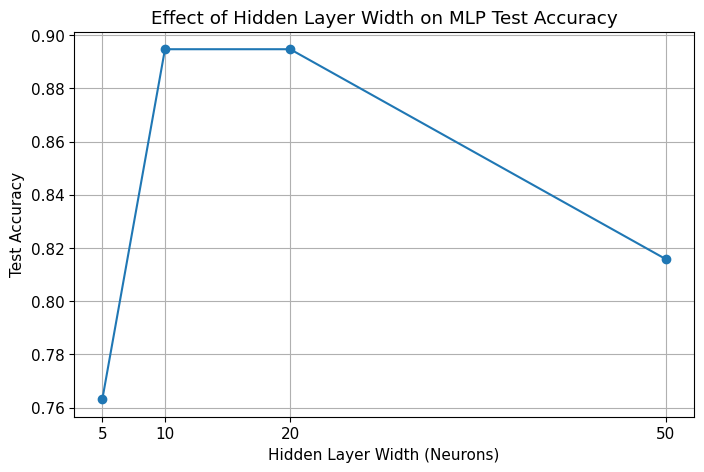

In [17]:
plt.plot(
    width_results_df["Width"],
    width_results_df["Test Accuracy"],
    marker="o"
)
plt.xticks(width_results_df["Width"])
plt.xlabel("Hidden Layer Width (Neurons)")
plt.ylabel("Test Accuracy")
plt.title("Effect of Hidden Layer Width on MLP Test Accuracy")
plt.grid(True)
plt.show()

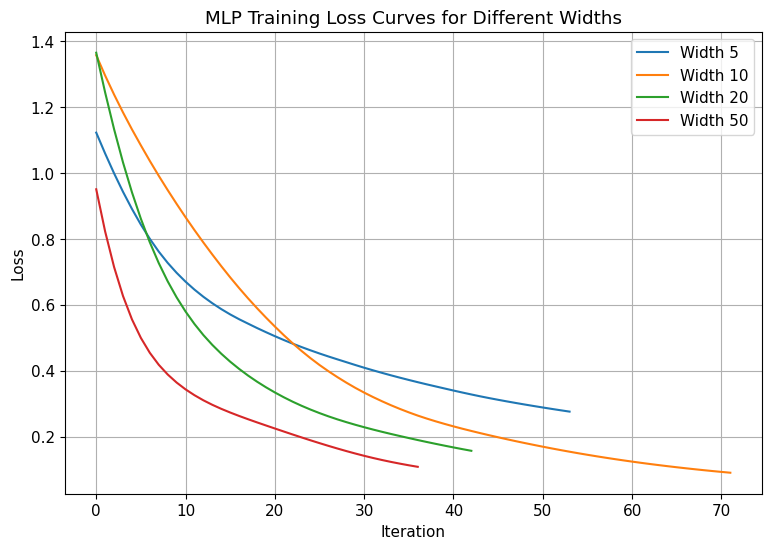

In [18]:
plt.figure(figsize=(9, 6))

for row in width_results:
    loss_curve = get_loss_curve(row["Model"])
    plt.plot(loss_curve, label=row["Configuration"])

plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("MLP Training Loss Curves for Different Widths")
plt.legend()
plt.grid(True)
plt.show()

In [19]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_results = []

combined_configs = {
    "Depth 1 | Width 10": (10,),
    "Depth 2 | Width 10": (10, 10),
    "Depth 3 | Width 10": (10, 10, 10),
    "Depth 1 | Width 20": (20,),
    "Depth 2 | Width 20": (20, 20)
}

for label, hidden_layers in combined_configs.items():
    model = build_mlp(hidden_layers=hidden_layers)
    scores = cross_val_score(model, X, y, cv=cv, scoring="accuracy")
    
    cv_results.append({
        "Configuration": label,
        "Hidden layers": hidden_layers,
        "Mean CV Accuracy": scores.mean(),
        "Std CV Accuracy": scores.std()
    })

cv_results_df = pd.DataFrame(cv_results).sort_values("Mean CV Accuracy", ascending=False)
cv_results_df

,Configuration,Hidden layers,Mean CV Accuracy,Std CV Accuracy
1,Depth 2 | Width 10,"(10, 10)",0.933333,0.042164
0,Depth 1 | Width 10,"(10,)",0.873333,0.092856
4,Depth 2 | Width 20,"(20, 20)",0.860000,0.048990
2,Depth 3 | Width 10,"(10, 10, 10)",0.846667,0.122202
3,Depth 1 | Width 20,"(20,)",0.833333,0.089443


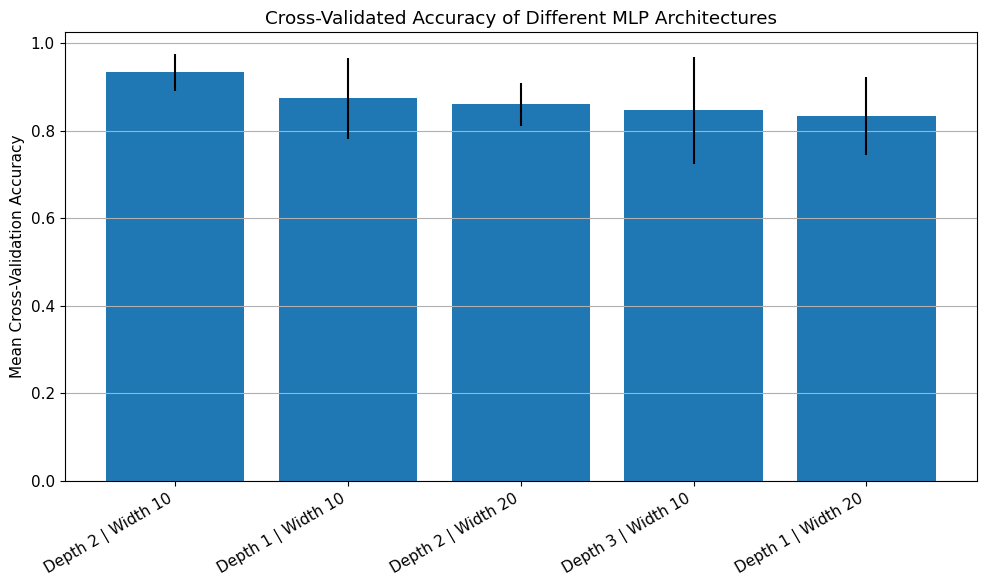

In [20]:
plt.figure(figsize=(10, 6))
plt.bar(cv_results_df["Configuration"], cv_results_df["Mean CV Accuracy"], yerr=cv_results_df["Std CV Accuracy"])
plt.xticks(rotation=30, ha="right")
plt.ylabel("Mean Cross-Validation Accuracy")
plt.title("Cross-Validated Accuracy of Different MLP Architectures")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

In [21]:
best_config = cv_results_df.iloc[0]["Hidden layers"]
best_label = cv_results_df.iloc[0]["Configuration"]

print("Best configuration based on CV:", best_label)

best_model = build_mlp(hidden_layers=best_config)
best_model.fit(X_train, y_train)
best_pred = best_model.predict(X_test)

best_test_acc = accuracy_score(y_test, best_pred)
print(f"Best Model Test Accuracy: {best_test_acc:.4f}")

Best configuration based on CV: Depth 2 | Width 10
Best Model Test Accuracy: 0.8421


In [22]:
print("Classification Report for Best MLP Model:\n")
print(classification_report(y_test, best_pred, target_names=class_names))

Classification Report for Best MLP Model:

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        12
  versicolor       0.82      0.69      0.75        13
   virginica       0.73      0.85      0.79        13

    accuracy                           0.84        38
   macro avg       0.85      0.85      0.85        38
weighted avg       0.85      0.84      0.84        38



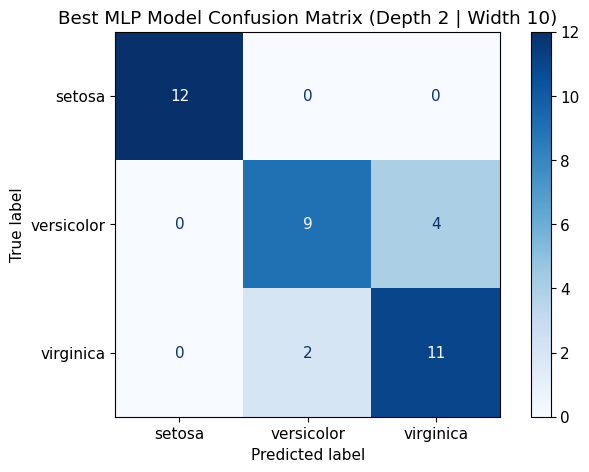

In [23]:
plot_confusion(
    y_test,
    best_pred,
    class_names,
    f"Best MLP Model Confusion Matrix ({best_label})"
)

In [24]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X)

X_pca_train, X_pca_test, y_pca_train, y_pca_test = train_test_split(
    X_pca, y,
    test_size=0.25,
    stratify=y,
    random_state=RANDOM_STATE
)

pca_model = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", MLPClassifier(
        hidden_layer_sizes=best_config,
        activation="relu",
        solver="adam",
        alpha=0.0005,
        learning_rate_init=0.01,
        max_iter=1500,
        random_state=RANDOM_STATE,
        early_stopping=True,
        validation_fraction=0.15,
        n_iter_no_change=30
    ))
])

pca_model.fit(X_pca_train, y_pca_train)
pca_pred = pca_model.predict(X_pca_test)
print("2D PCA model accuracy:", accuracy_score(y_pca_test, pca_pred))

2D PCA model accuracy: 0.6578947368421053


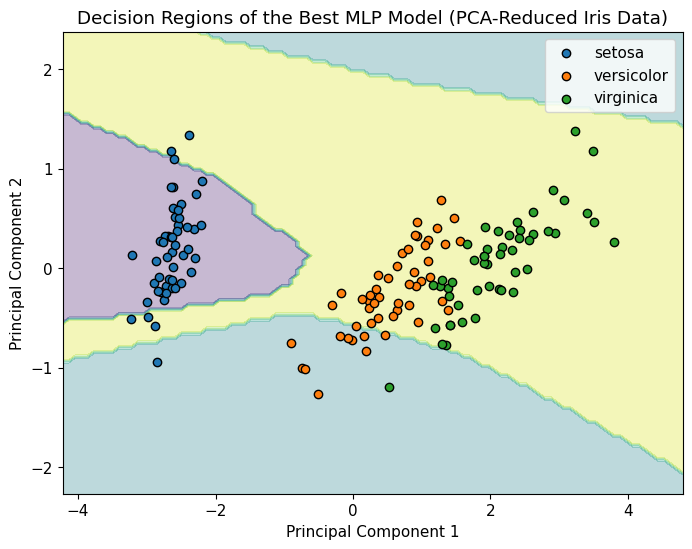

In [25]:
fig, ax = plt.subplots(figsize=(8, 6))

DecisionBoundaryDisplay.from_estimator(
    pca_model,
    X_pca,
    response_method="predict",
    alpha=0.3,
    ax=ax
)

for class_id, class_name in enumerate(class_names):
    ax.scatter(
        X_pca[y == class_id, 0],
        X_pca[y == class_id, 1],
        label=class_name,
        edgecolors="k"
    )

ax.set_title("Decision Regions of the Best MLP Model (PCA-Reduced Iris Data)")
ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
ax.legend()
plt.show()

In [26]:
comparison_df = pd.DataFrame({
    "Model": ["Logistic Regression", "Best MLP"],
    "Test Accuracy": [baseline_acc, best_test_acc]
})

comparison_df

,Model,Test Accuracy
0,Logistic Regression,0.921053
1,Best MLP,0.842105


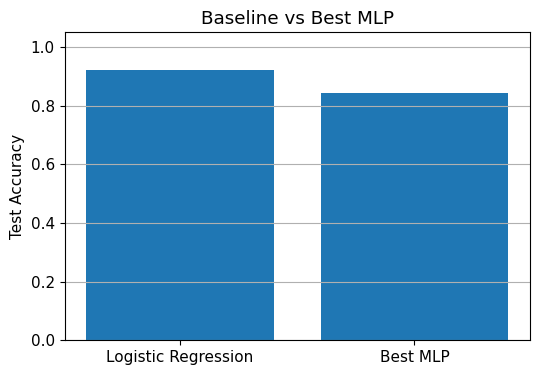

In [27]:
plt.figure(figsize=(6, 4))
plt.bar(comparison_df["Model"], comparison_df["Test Accuracy"])
plt.ylabel("Test Accuracy")
plt.title("Baseline vs Best MLP")
plt.ylim(0.0, 1.05)
plt.grid(axis="y")
plt.show()

In [28]:
summary_rows = []

for row in depth_results:
    summary_rows.append({
        "Experiment Type": "Depth",
        "Configuration": row["Configuration"],
        "Architecture": row["Hidden layers"],
        "Test Accuracy": row["Test Accuracy"]
    })

for row in width_results:
    summary_rows.append({
        "Experiment Type": "Width",
        "Configuration": row["Configuration"],
        "Architecture": row["Hidden layers"],
        "Test Accuracy": row["Test Accuracy"]
    })

summary_df = pd.DataFrame(summary_rows).sort_values("Test Accuracy", ascending=False)
summary_df

,Experiment Type,Configuration,Architecture,Test Accuracy
0,Depth,1 hidden layer,"(10,)",0.894737
5,Width,Width 10,"(10,)",0.894737
6,Width,Width 20,"(20,)",0.894737
2,Depth,3 hidden layers,"(10, 10, 10)",0.868421
3,Depth,4 hidden layers,"(10, 10, 10, 10)",0.868421
1,Depth,2 hidden layers,"(10, 10)",0.842105
7,Width,Width 50,"(50,)",0.815789
4,Width,Width 5,"(5,)",0.763158
